In [1]:
import SEACells
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
import seaborn as sns
import matplotlib.pyplot as plt
import os
import h5py
import stark as sk

In [2]:
num= 40
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])
pca_vec = np.load('/Users/ckw/warehouse/metacell/stark/test_output/pca_vec_500000.npy')
umap_vec = np.load('/Users/ckw/warehouse/metacell/stark/test_output/umap_vec_500000.npy')
cell_embeddings = pca_vec  # 或者 umap_vec，取决于你想用哪个作为输入
print(pca_vec.shape, umap_vec.shape, len(lb))
adata = ad.AnnData(cell_embeddings)
adata.obs['cell_type'] = lb
adata.obsm['X_pca'] = pca_vec
adata.obsm['X_umap'] = umap_vec

n_SEACells = num
build_kernel_on = 'X_pca' # key in ad.obsm to use for computing metacells
                        # This would be replaced by 'X_svd' for ATAC data

## Additional parameters
n_waypoint_eigs = 10 # Number of eigenvalues to consider when initializing metacells

model = SEACells.core.SEACells(adata, 
            build_kernel_on=build_kernel_on, 
            n_SEACells=n_SEACells, 
            n_waypoint_eigs=n_waypoint_eigs,
            convergence_epsilon = 1e-5,
                use_gpu =False)

model.construct_kernel_matrix()
M = model.kernel_matrix
model.initialize_archetypes()
model.fit(min_iter=10, max_iter=200)

adata.obs['metacell'] = adata.obs['SEACell'].apply(lambda x: int(x.split('-')[1]))
adata.obs.columns = ['label','SEAcell', 'metacell']
adata.uns['X_pca'] = pca_vec    
adata.uns['X_umap'] = umap_vec

hdata = sk.create_hdata_from_adata(adata,
                            data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
                        output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
                        genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
                        chrom_list=[f"chr{i}" for i in range(1, 23)],
                        resolution=500000)
purity_df, metrics = sk.tl.evaluate(hdata, hdata.obs['label'])
# result[num] = metrics

(700, 114) (700, 2) 700
Welcome to SEACells!
Computing kNN graph using scanpy NN ...


/var/folders/vj/gx99370d7_z4fq339y_07z700000gn/T/ipykernel_79415/242906330.py:11: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(cell_embeddings)
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Computing radius for adaptive bandwidth kernel...


  0%|          | 0/700 [00:00<?, ?it/s]

Making graph symmetric...
Parameter graph_construction = union being used to build KNN graph...
Computing RBF kernel...


...

/Users/ckw/opt/anaconda3/envs/ckw/lib/python3.10/site-packages/palantir-1.4.2-py3.10.egg/palantir/utils.py:348: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  temp = AnnData(data_df.values)


Constructing CSR matrix...
Building kernel on X_pca
Computing diffusion components from X_pca for waypoint initialization ... 
Done.
Sampling waypoints ...
Done.
Selecting 32 cells from waypoint initialization.
Initializing residual matrix using greedy column selection
Initializing f and g...


100%|██████████| 18/18 [00:00<00:00, 4495.77it/s]

Selecting 8 cells from greedy initialization.
Randomly initialized A matrix.


Setting convergence threshold at 0.00038
Starting iteration 1.
Completed iteration 1.
Starting iteration 10.
Completed iteration 10.
Converged after 16 iterations.

正在计算评估指标...
✅ 指标计算完成！(发现 14 种细胞类型)
----------------------------------------
简单平均纯度 (Mean Purity)  : 0.8164
模型准确率 (Accuracy)      : 0.8014
全局加权分 (Global Score)  : 0.5973
过度融合指标 (WCOS)       : 0.9614
Hub 权重不纯度 (HWIS)     : 0.9938
----------------------------------------
✅ 评估指标计算完成，纯度得分(EP_v2等)已同步至 hdata.metacells。


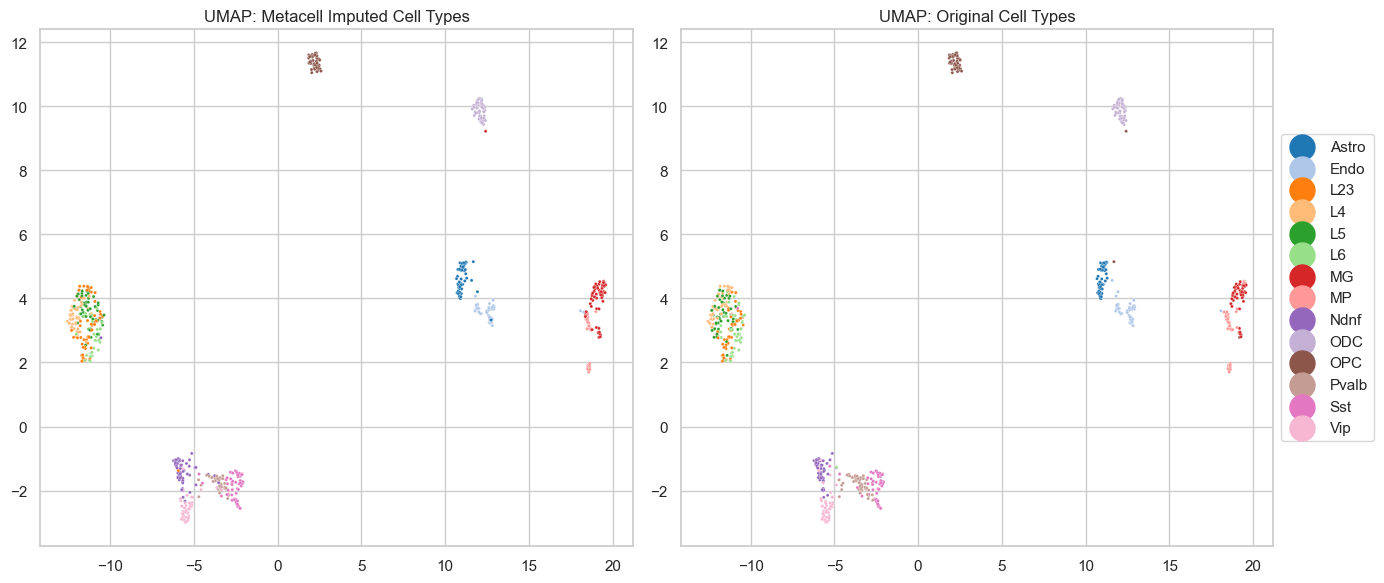

In [3]:
sk.pl.plot_umap_comparison(hdata, resolution=500000)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


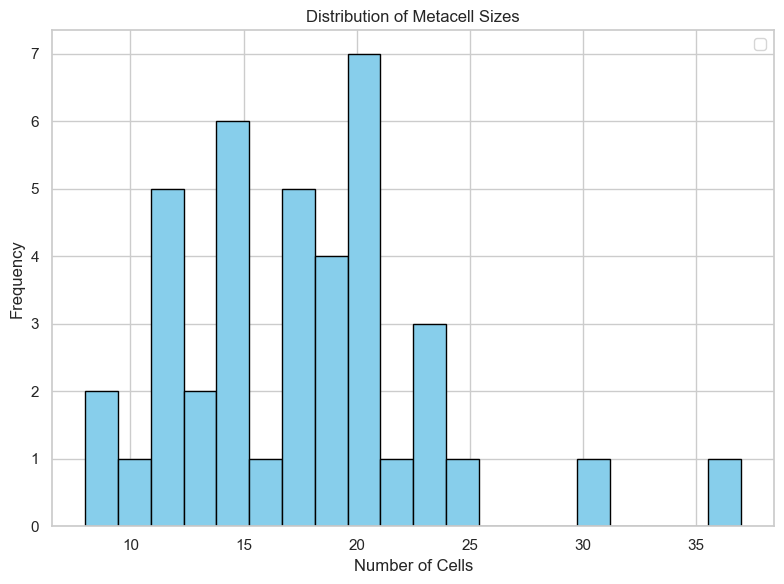

In [4]:
sk.pl.plot_metacell_sizes(hdata,)

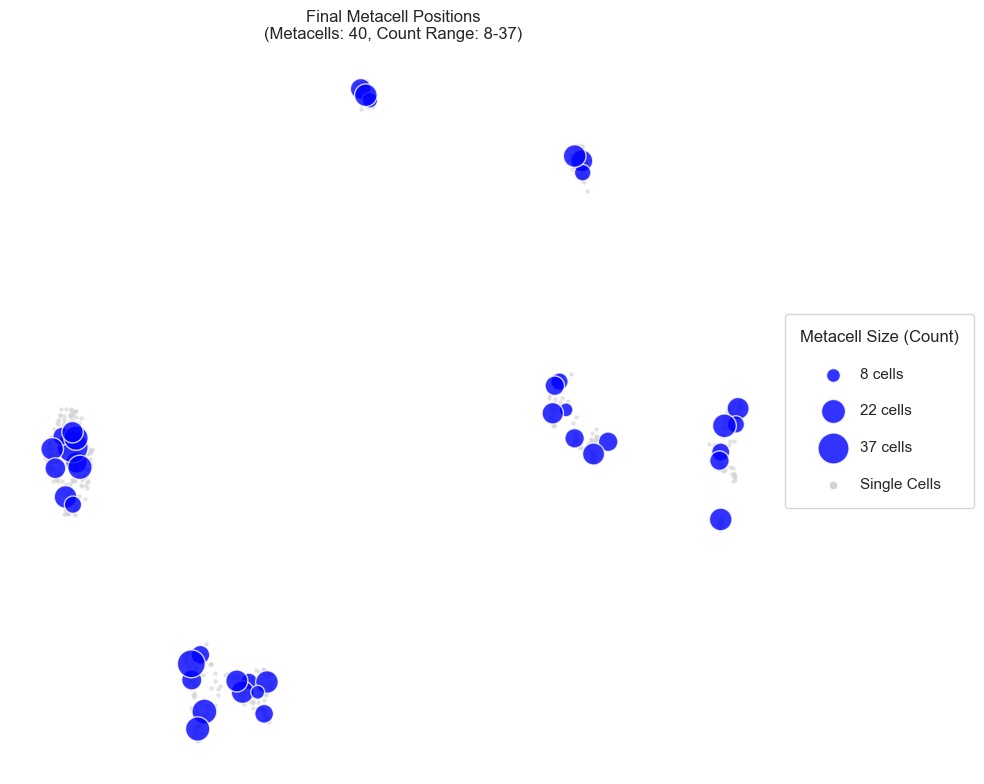

In [5]:
sk.pl.plot_metacells(hdata, resolution=500000, max_size=500, min_size=100)


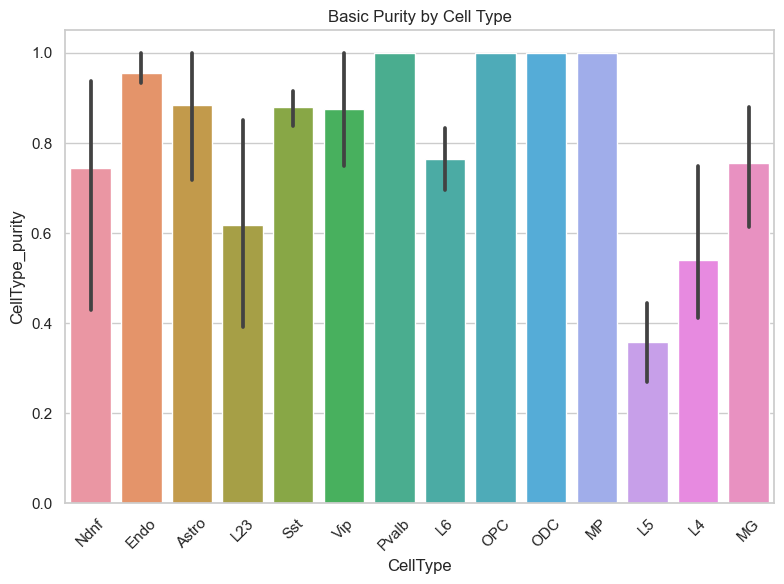

In [6]:
sk.pl.plot_basic_purity(hdata,)